#### pandas 활용 데이터 전처리 & 시각화 
- 외부프로그램 활용 : flourish
- 내부 시각화 라이브러리 | 모듈
  - matplotlib : 코드 학습이 꽤 난이도가 있는 편 // 오래됨
  - seaborn : matplotlib 를 활용해서 만든 그래프에 색상 및 레이아웃, 프레임 등을 조작
  - plotly : 현존하는 파이썬 데이터 시각화의 가장 최신 트렌드
  - EDA + pandas + plotly : 해당 조합이 가장 최신 데이터 시각화 조합 

#### plotly 
1) Plotly Express : px (*빠르고 간단한 시각화) 
    - 정말 짧은 코드로 괜찮은 시각적 그래프를 출력할 수 있음
    - 학습 속도가 빠르다 / EDA
    - 범례 / 2차원 다양한 종류 그래프 / 편집.가공
    - 디테일한 레이아웃 수정, 변경, 커스터마이징 x

2) Graph Objects : go (*세밀한 커스터마이징 필요) 
    - 코드의 길이가 길어짐 / 초심자에게는 어려움
    - 애니메이션, 인터랙티브한 레이블 설정 

In [1]:
pip install plotly 

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [ ]:
from plotly import express as px 

""" 
fig = px.그래프종류(
    데이터프레임,
    x="x축 열이름",
    y= "y축 열이름" ,
    title = "그래프제목" 
)

fig.show() # 그래프를 화면에 출력하는 명령어

1) scatter (*산점도) 

2) line (*선)

3) bar (*막대)

4) histogram (*히스토그램)

5) box (*상자그림)
""" 

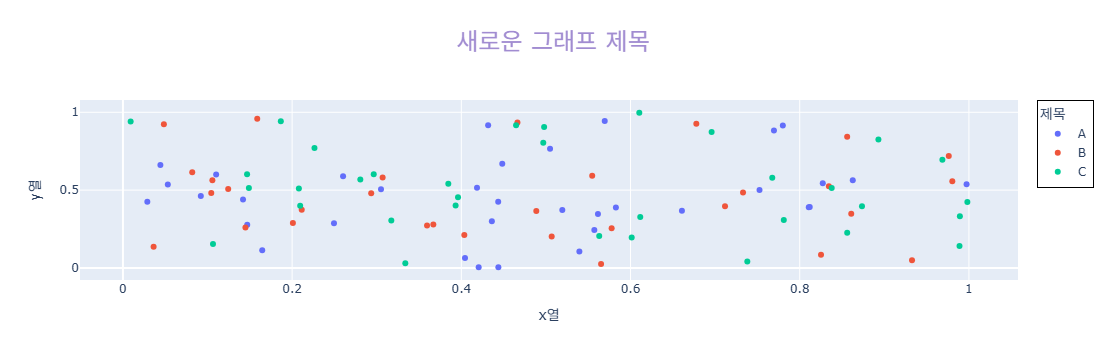

In [77]:
#

import plotly.express as px 
import pandas as pd 
import numpy as np 

df = pd.DataFrame({
    "x열" : np.random.rand(100), # 0~1 미만의 난수형태의 값을 100개 생성 
    "y열" : np.random.rand(100), # 0~1 미만의 난수형태의 값을 100개 생성 
    "색상기준열" : np.random.choice(["A","B","C"],100),
})

fig = px.scatter(
    df,
    x="x열",
    y="y열",
    color = "색상기준열",
    title = "scatter"
)

fig.update_layout(
    title = {
        "text": "새로운 그래프 제목",
        "font": {"size":24, "color":"#a18cd1"},
        "x": 0.5,
    },
    # legend ={
    #     "title" : "제목" ,
    #     "x" : 1.02,
    #     "y" : 1,
    #     "bordercolor":"#00f",
    #     "borderwidth":1
    # }
    legend =dict(title="제목",x=1.02,y=1,bordercolor="black",borderwidth=1)
)
fig.show()

#### 산점도 그래프 활용 방법 
1) 관계분석 : 서로 다른 변수 사이에 상관관계가 존재하는지 파악하고 싶을 때 
2) 패턴 및 경향성 파악 : 특정 데이터들이 어떤 패턴이나 경향성을 보이는지 확인하고자 할 때 
3) 이상치(outlier) 탐지 : 전체 데이터에서 특정 데이터가 다른 값들과 동떨어진 좌표값 = 이상치를 가지고 있을 때, 식별 
4) 탐색적 데이터 분석 초반 단계 : 전체 총 데이터안에 있는 feature 들 간 상관관계 = 상호작용 여부를 판단하고자 할 때 

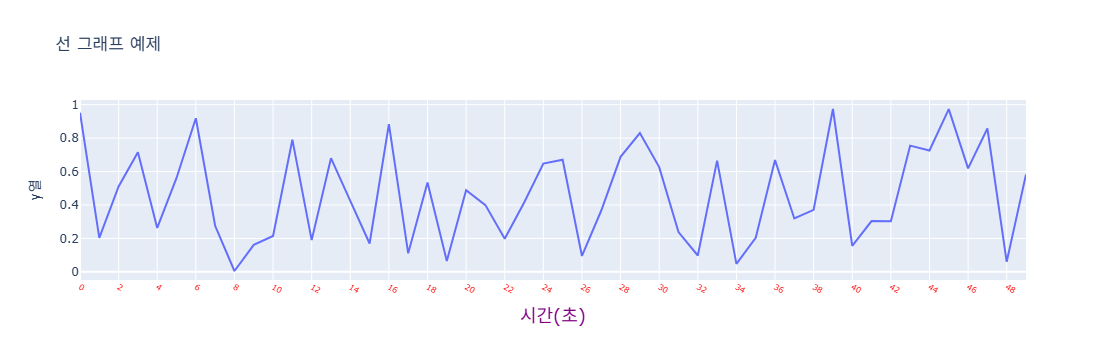

In [93]:
# 

df = pd.DataFrame({
    "x열" :np.arange(50),
    "y열" :np.random.rand(50),
})

fig = px.line(
    df,
    x= "x열",
    y = "y열",
    title = "선 그래프 예제"
)

fig.update_xaxes(
    title="시간(초)",
    # title_font={
    #     "size":18,
    #     "color":"purple"
    # }
    title_font=dict(size=18,color="purple"),
    tickangle = 30,
    dtick = 2,
    # tickfont={
    #     "size":12
    # }
    tickfont=dict(size=8,color="red")
)

fig.show()

#### 선 그래프 
- 선 그래프 : 순차적인 순서에 따른 값의 변화를 선으로 연결해서 보고 싶을 때 

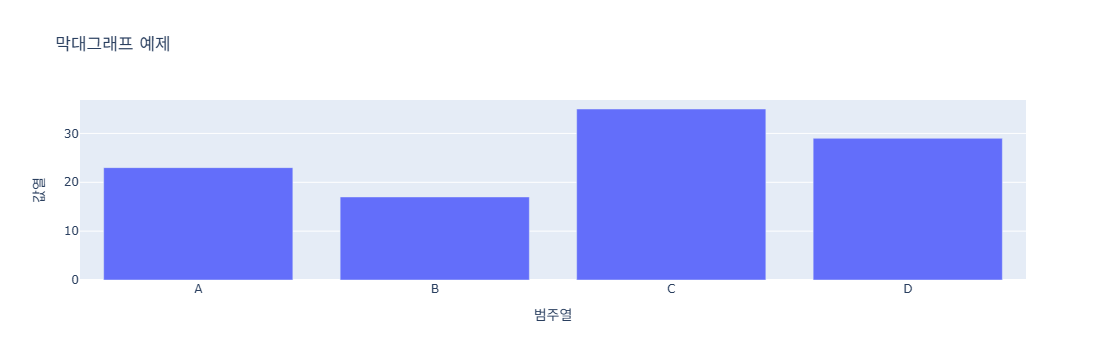

In [14]:
import plotly.express as px 
import pandas as pd 
import numpy as np 

df = pd.DataFrame({
    "범주열" : ["A","B","C","D"],
    "값열":[23,17,35,29]
})

fig = px.bar(
    df,
    x = '범주열',
    y = '값열',
    title = "막대그래프 예제"
)

fig.show()

#### 막대그래프 
- 범주별 -> 범위별 막대의 높이로 비교해서 데이터를 분석 => m/s , 기간별 비교 (2020 vs 2021 vs 2022...) 

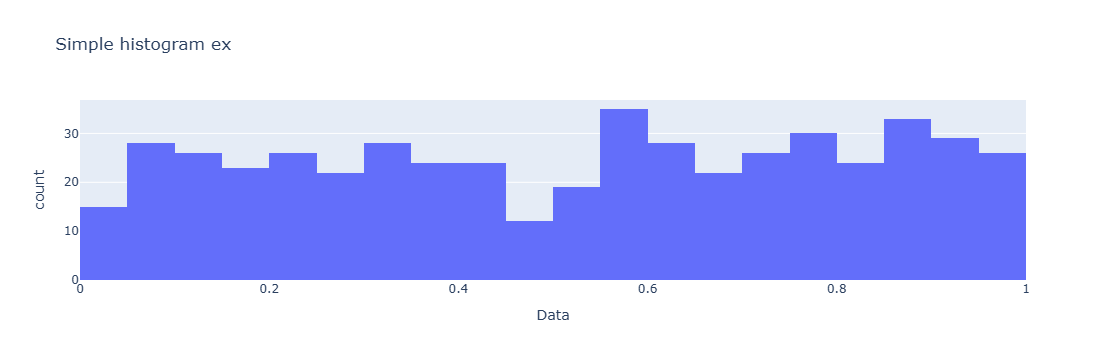

In [21]:
# 히스토그램 => 연속형 데이터의 분포를 구간별 막대로 나타내고자 할 때

import plotly.express as px 
import pandas as pd 
import numpy as np

df = pd.DataFrame({
    "Data" : np.random.rand(500),
})

fig = px.histogram(
    df,
    x="Data",
    nbins=30, #number of bins = 구간의 개수 
    title ="Simple histogram ex"
)

fig.show()

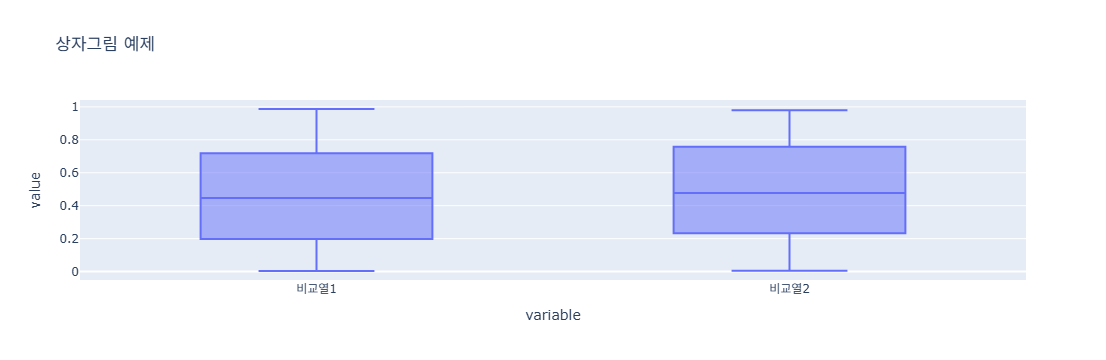

In [29]:
# 

df = pd.DataFrame({
    "비교열1" : np.random.rand(100),
    "비교열2" : np.random.rand(100)
})

fig = px.box(
    df,
    y = ["비교열1","비교열2"],
    title = "상자그림 예제"
)
fig.show()

#### 상자그림 그래프 
- 여러개 열의 데이터 분포,중앙값,사분위수 및 이상치를 한눈에 확인 및 비교하고자 할 때 그래프
- 사분위수 계산 :
  - Q1 데이터의 하위 25%
  - Q3: 데이터의 상위
  - 이상치 : 최저값 0% 미만, 죄초값 100% 초과
  - 이상치 값을 계산하기 위한 공식
     => Q3-Q1 = IQR = Interquartile Range
     => 하한 이상치 = Q1 - IQR x 1.5
     => 상한 이상치 = Q3 + IQR x 1.5
     => 하한보다 작은 값이 나왔거나, 혹은 상한보다 높은 값이 나왔다 => 특이점 발생
     => 해당 특이점으로부터 발견해야하는 인사이트, 도출해야하는 문제점 

In [ ]:
# 각 개별 그래프의 세부요소 변경 
# 옵션 => 정말 다양 // 업데이트 빈번함 
# 1) update_layout() : 해당 그래프에 대한 전체 레이아웃 수정 => 제목,범례,여백 
# 2) update_xaxes() : x 축에 해당되는 속성 요소 수정 => 제목, 글꼴, 눈금 등
# 3) update_yaxes() : y 축에 해당되는 속성 요소 수정 => 제목, 글꼴, 눈금 등 

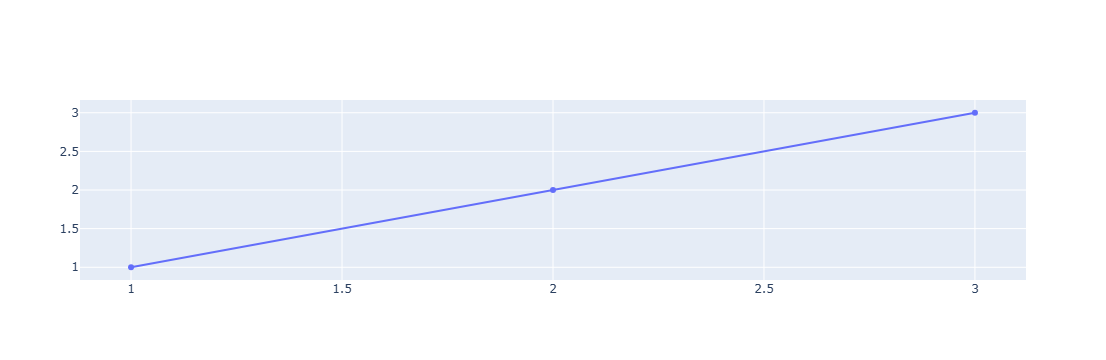

In [94]:
# import plotly.express as px       px,go 와 같은 별칭은 관례적으로 사용함 
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=[1,2,3],
        y=[1,2,3]
    )
)

fig.show()